<a href="https://colab.research.google.com/github/aditi2134/placement_prediction/blob/main/placementml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("/content/placement.csv")
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
display(df.head())

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
print(df.columns)

Index(['cgpa', 'iq', 'placement'], dtype='object')


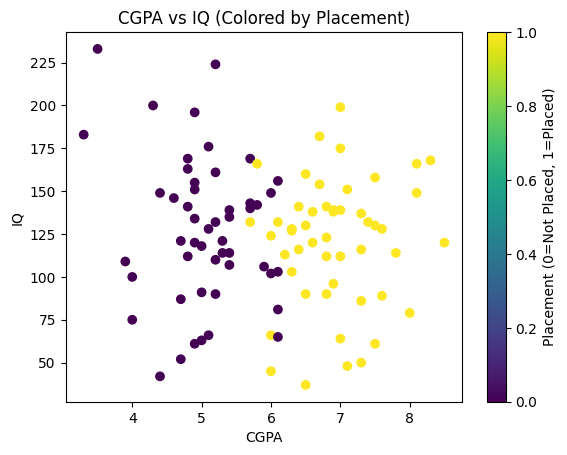

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'], df['iq'], c=df['placement'], cmap='viridis')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('CGPA vs IQ (Colored by Placement)')
plt.colorbar(label='Placement (0=Not Placed, 1=Placed)')
plt.show()

In [ ]:
X = df[['cgpa', 'iq']]
y = df['placement']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [42]:
y_pred = model.predict(X_test)

In [40]:
y_test

,placement
83,1
53,1
70,1
45,1
44,1
39,0
22,0
80,0
10,1
0,1


In [43]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.85


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


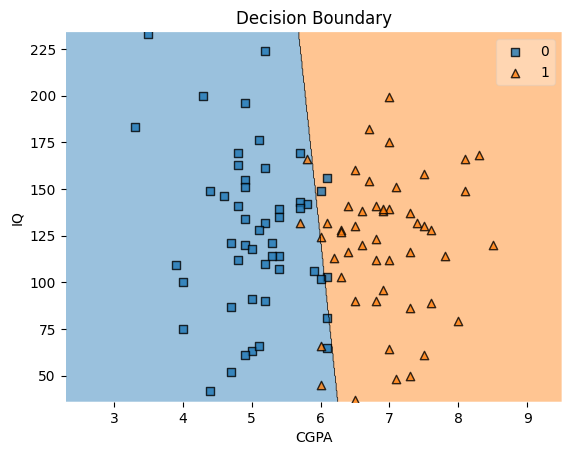

In [44]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, y.values, clf=model)
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Decision Boundary')
plt.show()

In [46]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))